## Start
-------------------------

Import libs and datasets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

df_game = pd.read_csv("video_game.csv")
df_murder = pd.read_csv("france_murder.csv")

## Analyse murder rate 
-------------------------

In [4]:
print(df_murder.head())

   Unnamed: 0  Murder/Homicide Rate
0        1990                  2.40
1        1991                  2.39
2        1992                  2.36
3        1993                  2.66
4        1994                  2.46


In [5]:
m_year = df_murder["Unnamed: 0"]
m_murder = df_murder["Murder/Homicide Rate"]

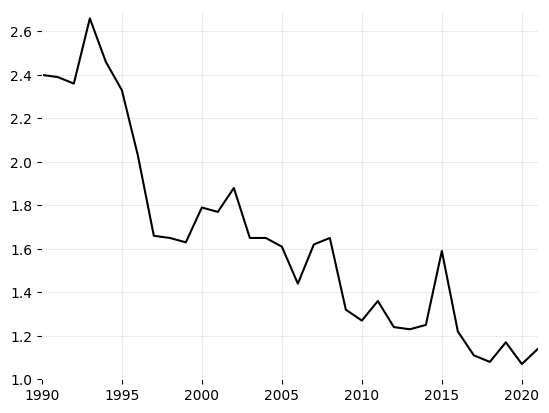

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(m_year, m_murder, color="black")
ax.fill_between(m_year, m_murder, 1, alpha=0.3, color="white")

# axes blancs
ax.tick_params(colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")

# bordures blanches
for spine in ax.spines.values():
    spine.set_color("white")

ax.set_xlim(1990, 2021)
ax.set_ylim(1, 2.7)

ax.grid(alpha=0.25)

# fond transparent
fig.patch.set_alpha(0)

#plt.savefig("../image/murder_rate.png", dpi=300, transparent=True)
plt.show()

## Analyse Video games
-------------------------

In [23]:
print(df_game.head())

                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37           NaN   

   Critic_Count User_Score  User_Count Developer Rating 

In [24]:
df_game = df_game.dropna(subset=["Year_of_Release"])

v_year = df_game["Year_of_Release"].astype(int)
v_genre = df_game["Genre"]

v_freq = pd.crosstab(v_year, v_genre)

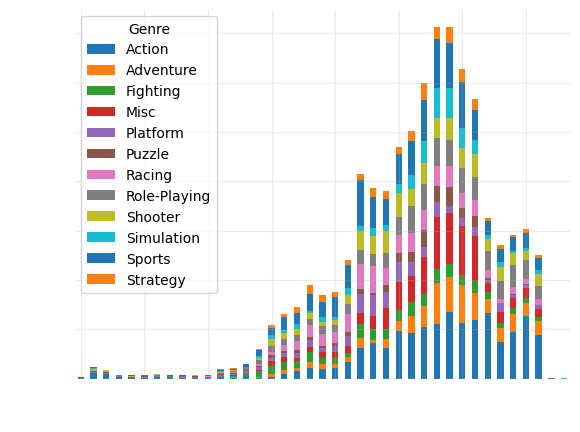

In [31]:
fig, ax = plt.subplots()

v_freq.plot.bar(stacked=True, ax=ax)

ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of games", color="white")
plt.xticks(rotation=0)
# espacer les années
ax.set_xticks(range(0, len(v_freq.index), 5))
ax.set_xticklabels(v_freq.index[::5])

ax.tick_params(colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(alpha=0.25)

fig.patch.set_alpha(0)

#plt.savefig("../image/game_by_gender.png", dpi=300, transparent=True)
plt.show()

In [51]:
genres_wanted = ["Action", "Fighting", "Shooter"]

df_filtered = df_game[df_game["Genre"].isin(genres_wanted)].copy()
df_filtered["Year_of_Release"] = df_filtered["Year_of_Release"].astype("Int64")

freq = pd.crosstab(df_filtered["Year_of_Release"], df_filtered["Genre"])
freq = freq.loc[1990:2015]

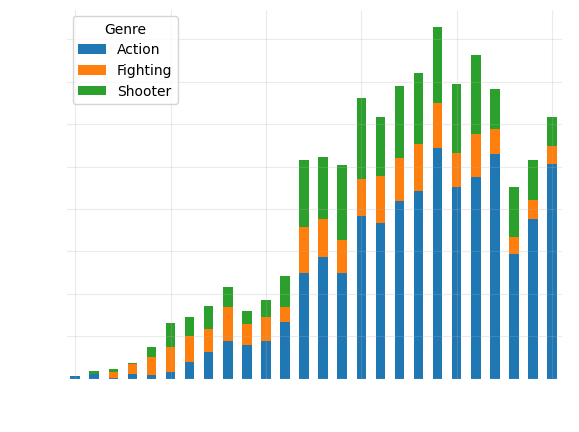

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

freq.plot.bar(stacked=True, ax=ax)

ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of games", color="white")

# espacer les années
ax.set_xticks(range(0, len(freq.index), 5))
ax.set_xticklabels(freq.index[::5], rotation=0)

# couleur des ticks
ax.tick_params(colors="white")

# bordures
for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(alpha=0.25)

# fond transparent
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.savefig("../image/game_genre_count.png", dpi=300, transparent=True)

plt.show()

In [55]:
genres_wanted = ["Action", "Fighting", "Shooter"]
df_filtered = df_game[df_game["Genre"].isin(genres_wanted)]

year = df_filtered["Year_of_Release"].astype(int)
genre = df_filtered["Genre"]

freq = pd.crosstab(year, genre)
sales_by_genre = df_filtered.groupby([year, genre])["Global_Sales"].sum().unstack(fill_value=0)
sales_by_genre = sales_by_genre.loc[1990:2015]

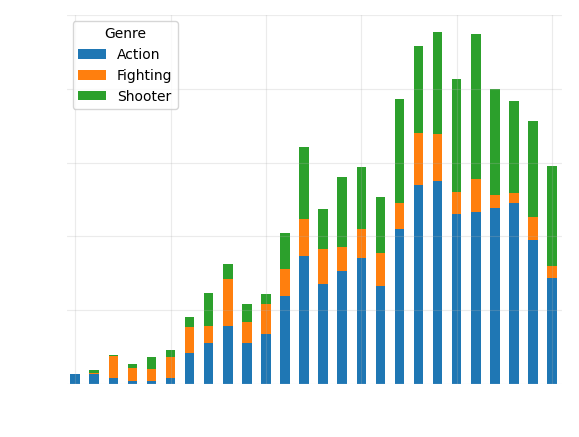

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sales_by_genre.plot.bar(stacked=True, ax=ax)

ax.set_xlabel("Year", color="white")
ax.set_ylabel("Global sales", color="white")

# espacer les années
ax.set_xticks(range(0, len(sales_by_genre.index), 5))
ax.set_xticklabels(sales_by_genre.index[::5], rotation=0)

# ticks blancs
ax.tick_params(colors="white")

# bordures blanches
for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(alpha=0.25)

# fond transparent
fig.patch.set_alpha(0)

plt.savefig("../image/game_gender_pondered.png", dpi=300, transparent=True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# données
y = sales_by_genre[genres_wanted].sum(axis=1)
x = sales_by_genre.index.astype(int)

# fit polynomial
coef = np.polyfit(x, y, deg=4)
poly = np.poly1d(coef)

y_fit = poly(x)

fig, ax = plt.subplots()

ax.plot(x, y, "o", label="Data", color="white")
ax.plot(x, y_fit, label="Polynomial fit (deg 4)", color="blue")

ax.set_xlabel("Year", color="white")
ax.set_ylabel("Global Sales", color="white")

# espacer les années
ax.set_xticks(x[::5])
ax.set_xticklabels(x[::5], rotation=0)

# ticks blancs
ax.tick_params(colors="white")

# bordures blanches
for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(alpha=0.25)

ax.legend()

# fond transparent
fig.patch.set_alpha(0)

plt.savefig("../image/game_fitting.png", dpi=300, transparent=True)
plt.show()

In [ ]:
y_fit = pd.Series(poly(x), index=x)
murder_series = df_murder.set_index("Unnamed: 0")["Murder/Homicide Rate"]
murder_series.index = murder_series.index.astype(int)

common_years = y_fit.index.intersection(murder_series.index)

sales_aligned = y_fit.loc[common_years]
murder_aligned = murder_series.loc[common_years]
corr = sales_aligned.corr(murder_aligned)
print(corr)

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# ventes (fit)
ax1.plot(common_years, sales_aligned, color="blue", linewidth=2, label="Game sales fit")
ax1.set_xlabel("Year", color="white")
ax1.set_ylabel("Global Sales", color="white")

# axe homicide
ax2 = ax1.twinx()
ax2.plot(common_years, murder_aligned, color="white", linestyle="--", linewidth=2, label="Murder rate")
ax2.fill_between(common_years, murder_aligned, 1, alpha=0.3, color="white")
ax2.set_ylabel("Murder/Homicide Rate", color="white")

# ticks blancs
ax1.tick_params(colors="white")
ax2.tick_params(colors="white")

# bordures blanches
for spine in ax1.spines.values():
    spine.set_color("white")
for spine in ax2.spines.values():
    spine.set_color("white")

# espacer les années
ax1.set_xticks(common_years[::5])

# grille
ax1.grid(alpha=0.25)

# fond transparent
fig.patch.set_alpha(0)

plt.savefig("../image/game_vs_murder.png", dpi=300, transparent=True)
plt.show()